What's being asked:

1. PD model: train a classifier that outputs the probability a borrower defaults

2. Expected loss function: calculate how much money the bank loses on that loan using the probability 

Expected loss formula: PD x LGD x EAD 

PD - Probability of default

LGD - Loss Given Default    -   % of loan loss if default

EAD - Exposure At Default   -   How much is owed

(10000, 8)

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0



Default distribution:


default
0    8149
1    1851
Name: count, dtype: int64

default
0    0.815
1    0.185
Name: proportion, dtype: float64

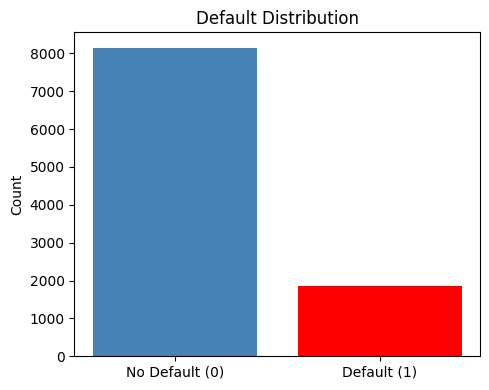

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)

df = pd.read_csv('Loan_Data.csv')

display(df.shape)
display(df.head())
# display(df.dtypes)

# # check for missing values
# print("\nMissing Values:")
# display(df.isnull().sum())

# how many people defaulted vs who didn't
print("\nDefault distribution:")
display(df['default'].value_counts())
display(df['default'].value_counts(normalize = True).round(3))

# plot it
plt.figure(figsize=(5,4))
# plt.bar(x_labels, heights)
plt.bar(['No Default (0)', 'Default (1)'], 
        df['default'].value_counts().sort_index(),
        color = ['steelblue', 'red'])
plt.title("Default Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig('default_distribution.png', dpi=150)
plt.show()

block 2: preprocessing

- drop customer id (not a feature)

- split into train/test BEFORE scaling to avoid data leakage

- scale feature so fico_score(300-850) doesn't over power income

In [56]:
X = df.drop(columns = ['default'])
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# fit scaler to train only, apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train_scaled.shape)
print("Test size:", X_test_scaled.shape)
print("Features:", list(X.columns))

Train size: (8000, 6)
Test size: (2000, 6)
Features: ['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score']


the above two blocks tell us:

- 10,000 total borrowers, 6 features, no missing values

- 81.5% no default, 18.5% defaulted

Block 3: train logistic regression

Sample predicted probabilities (first 10): 


array([0.    , 0.0081, 1.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.9997, 0.    ])

Actual labels (first 10):


array([0, 0, 1, 0, 0, 0, 0, 0, 1, 0])


Feature Coefficients:


,Feature,Coefficients
0,credit_lines_outstanding,8.931731
2,total_debt_outstanding,3.715826
1,loan_amt_outstanding,0.124476
5,fico_score,-1.202141
3,income,-2.323593
4,years_employed,-2.874120


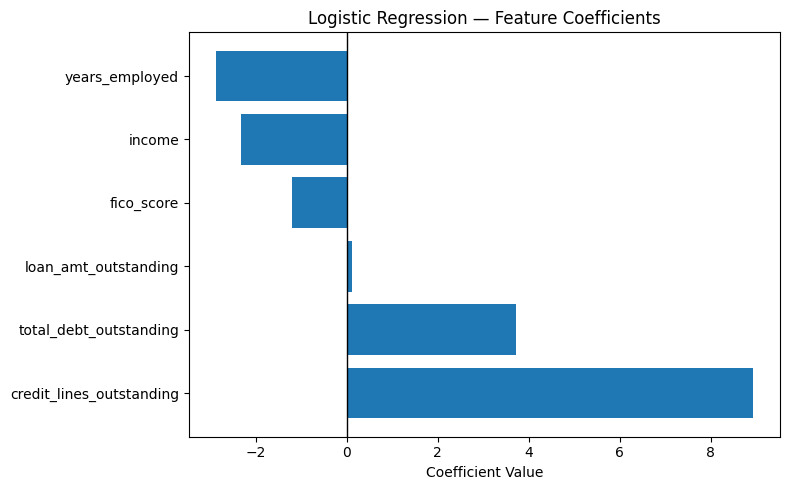

In [87]:
lr_model = LogisticRegression(max_iter = 1000, random_state = 42)
lr_model.fit(X_train_scaled, y_train)

# predict_proba returns [P(no default), P(default)] for each borrower
# we want column 1 -> probability of default
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

y_pred_lr = lr_model.predict(X_test_scaled)     # hard prediction: 0 or 1

print("Sample predicted probabilities (first 10): ")
display(np.round(y_prob_lr[:10], 4))

print("Actual labels (first 10):")
display(y_test.values[:10])

# feature coefficients: which variables drive default risk (higher value = higher risk)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficients': lr_model.coef_[0]
}).sort_values('Coefficients', ascending = False)

print("\nFeature Coefficients:")
display(coef_df)

plt.figure(figsize = (8,5))
plt.barh(coef_df['Feature'], coef_df['Coefficients'])
plt.axvline(x = 0, color = 'black', linewidth = 1)      # zero ref line
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression — Feature Coefficients')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150)
plt.show()

credit_lines_outstanding = 8.93 : highest by far, meaning more credit lines = much higher default risk

total_dept_outstanding = 3.72 : more total dept = high risk 

years_employed = -2.87 : longer job stability = lower risk

income = -2.32 : higher income = lower risk

Block 4: Evaluate the model

Accuracy -> overall correct predictions

ROC AUC -> measures how well a model can distinguish between a positive class and a negative class (defaulter and non defaulter), where 1 is perfect and 0.5 is random guessing

Accuracy:  0.9955
ROC AUC:  0.9893
Classification Report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1652
           1       0.99      0.98      0.99       348

    accuracy                           1.00      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Confusion Matrix:
  [[1650    2]
 [   7  341]]


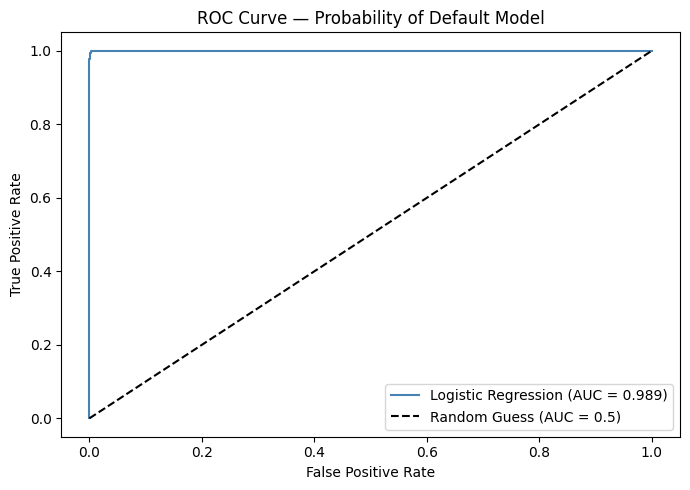

In [96]:
accuracy = accuracy_score(y_test, y_pred_lr)        # predicts actual answers with model prediction
auc = roc_auc_score(y_test, y_pred_lr)

print(f"Accuracy: {accuracy: .4f}")
print(f"ROC AUC: {auc: .4f}")

print("Classification Report: ")
print(classification_report(y_test, y_pred_lr))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n ", cm)
# [[TN  FP]
#  [FN  TP]]
# FN = predicted safe but actually defaulted -> worst outcome for the bank

# plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Probability of Default Model')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
